# Non-reversible vs reversible anchored Langevin — **L1-smooth ball**

Same protocol as `accuracy_curves_only.ipynb`, with the constraint set swapped.
**One figure only: training accuracy and test accuracy against iteration.**
Supporting statistics are reported as tables, not plots.

## The constraint

The L1-smooth ball is the $p=1$ member of the same smoothed-$\ell^p$ family as
the quartic set ($p=4$) used earlier — a smooth surrogate for $\sum_i|\beta_i|\le R$:

$$K=\Bigl\{\beta:\;g(\beta)=\sum_{i=1}^{d}\sqrt{\beta_i^2+\varepsilon^2}\;\le\;\Lambda\Bigr\},
\qquad \Lambda=d\varepsilon+R,\qquad D=\Lambda-d\varepsilon=R,$$

$$H_K(\beta)=\frac{g(\beta)-d\varepsilon}{D}\in[0,1],\qquad
\partial_i g=\frac{\beta_i}{\sqrt{\beta_i^2+\varepsilon^2}},\qquad
\nabla H_K=\frac{\nabla g}{D}.$$

$J$ keeps the block structure with $J_{I_\ell,I_\ell}=[-s_\ell\nabla_{I_\ell}g]_\times$,
since the normal here is parallel to $\nabla g$, not to $\beta$.

Two methods only, both anchored ($\rho=\log 2$), differing solely in $\alpha$.

## Choosing $\varepsilon$, $R$ and $s$ — matched to the unit-ball run

$s=5$ cannot simply be carried over. $\partial_i g=\beta_i/\sqrt{\beta_i^2+\varepsilon^2}$
saturates towards $\pm1$, so $\|J\|$ is far larger here than on the Euclidean ball
at the same $s$, and $s=5$ lands deep in the regime where the projection fires on
40 % of iterations. Carrying the number over unchanged would be changing the
experiment, not preserving it.

So the two free constants are matched to the unit-ball configuration on the
quantities that actually drive the dynamics:

| quantity | unit ball ($s=5$) | L1-smooth ball | matched by |
|---|---|---|---|
| anchor level $H_K(\beta_{\text{true}})$ | 0.4725 | 0.470 | $R=1.9$ |
| perturbation size $\|\alpha Jv\|/\|v\|$ | 2.50 | 2.38 | $s=2.0$ |
| projection rate | 0.168 | 0.110 | (consequence) |

Everything else is untouched: same data pipeline, AR(1) predictors
$\rho_x=0.99$, $h=10^{-4}$, $m=50$, $R=100$ replicates, 1000 iterations, same
seeds, same paired comparison and the same held-out-seed confirmation.

In [1]:
import os, sys, time
import numpy as np, pandas as pd, matplotlib
import matplotlib.pyplot as plt
from IPython.display import display

sys.path.insert(0, os.path.abspath("."))
import anchored_sgld as nral

pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.5f}")

QUICK  = os.environ.get("NRAL_QUICK", "0") == "1"
MODE   = "QUICK MODE" if QUICK else "FULL"
SUFFIX = "_quick" if QUICK else ""
OUTPUT_DIR = "results_l1smooth"; os.makedirs(OUTPUT_DIR, exist_ok=True)

BLOCK_STRENGTH = 2.0      # matched on ||alpha J v|| / ||v||
L1_RADIUS      = 1.9      # matched on H_K(beta_true)
RHO_X          = 0.99
GEOMETRY       = "l1smooth"
HELD_OUT_SEEDS = (101,) if QUICK else (101, 202, 303)

cfg = nral.ExperimentConfig(
    n_repeats        = 20  if QUICK else 100,
    n_iterations     = 300 if QUICK else 1000,
    checkpoint_every = 10,
    block_scales     = (BLOCK_STRENGTH,) * 3,
    l1_radius        = L1_RADIUS,
)
print(f"=== {MODE} ===")
print(f"d = {cfg.d}, n_train = {cfg.n_train}, n_test = {cfg.n_test}, m = {cfg.batch_size}")
print(f"h = {cfg.step_size}, iterations = {cfg.n_iterations}, R = {cfg.n_repeats}")
print(f"constraint = L1-smooth ball, epsilon = {cfg.epsilon}, l1_radius = {cfg.l1_radius}")
print(f"block strengths s = {tuple(float(x) for x in cfg.scales)}")
print(f"rho = log 2 = {nral.RHO_ANCHORED:.6f} for BOTH methods; alpha = 0 vs 1")
print(f"seeds: data={cfg.data_seed}, split={cfg.split_seed}, sampler={cfg.sampler_seed}")

=== FULL ===
d = 9, n_train = 1600, n_test = 400, m = 50
h = 0.0001, iterations = 1000, R = 100
constraint = L1-smooth ball, epsilon = 0.2, l1_radius = 1.9
block strengths s = (2.0, 2.0, 2.0)
rho = log 2 = 0.693147 for BOTH methods; alpha = 0 vs 1
seeds: data=2026, split=2027, sampler=3000


## Data and geometry

Same generative pipeline as before, with AR(1)-correlated predictors. The data
set and split are frozen across both methods and all replicates, so the
replicate spread measures sampler randomness only.

In [2]:
dataset  = nral.make_correlated_dataset(cfg, RHO_X)
geometry = nral.make_geometry(GEOMETRY, cfg)
beta_true = dataset.beta_true

print(f"X_train {dataset.X_train.shape}, X_test {dataset.X_test.shape}")
print(f"posterior condition number: {nral.posterior_condition_number(dataset):.0f}")
print(f"\ng_min = d*eps = {geometry.g_min:.3f};  Lambda = g_min + R = {geometry.Lambda:.3f};  D = {geometry.D:.3f}")
print(f"g(beta_true) = {float(geometry.constraint_value(beta_true)):.4f} <= {geometry.Lambda:.3f}  -> feasible")
print(f"H_K(beta_true) = {float(geometry.H(beta_true)):.4f}   (unit-ball reference 0.4725)")
_ = geometry.sample_uniform(np.random.default_rng(0), 2000)
print(f"uniform-initialisation acceptance rate = {geometry.last_acceptance_rate:.4f}")

X_train (1600, 9), X_test (400, 9)
posterior condition number: 1225

g_min = d*eps = 1.800;  Lambda = g_min + R = 3.700;  D = 1.900
g(beta_true) = 2.6933 <= 3.700  -> feasible
H_K(beta_true) = 0.4701   (unit-ball reference 0.4725)
uniform-initialisation acceptance rate = 0.1388


### Implementation checks for the new geometry

The L1-smooth ball is new code, so it is verified to the same standard as the
other two geometries before it is used.

In [3]:
checks = {
    "J identities": nral.check_matrix_identities(geometry, cfg.scales),
    "anchor bounds": nral.check_anchor_bounds(geometry),
    "projection": nral.check_projection(geometry, n_points=30, scale=1.5),
    "J grad_U0 nonzero": nral.check_J_gradU0_nonzero(dataset, geometry, cfg.scales),
}
for name, values in checks.items():
    print(name)
    print("    " + ", ".join(
        f"{k} = {v:.3e}" if abs(v) < 1e-3 or abs(v) > 1e4 else f"{k} = {v:.6g}"
        for k, v in values.items()))

# Independent cross-check of the projection: vectorised bisection vs scalar brentq.
rng = np.random.default_rng(11)
worst = 0.0
for _ in range(15):
    z = rng.normal(scale=1.5, size=cfg.d)
    fast = geometry.project(z).beta
    reference = (geometry._project_one(z)[0]
                 if geometry.constraint_value(z) > geometry.Lambda else z)
    worst = max(worst, float(np.abs(fast - reference).max()))
print(f"projection: vectorised bisection vs scalar brentq = {worst:.3e}")

assert checks["J identities"]["max_skew_error"] < 1e-12          # J^T = -J
assert checks["J identities"]["max_divergence"] < 1e-8           # div J = 0
assert checks["J identities"]["max_tangency_on_boundary"] < 1e-10  # J n = 0
assert checks["J identities"]["max_J_gradH"] < 1e-10             # J grad_H = 0
assert checks["J identities"]["max_matrix_free_vs_explicit"] < 1e-10
assert checks["anchor bounds"]["bounds_hold"] == 1.0             # 1/2 <= a <= 1
assert checks["projection"]["max_kkt_residual"] < 1e-8
assert checks["projection"]["max_feasibility_excess"] < 1e-8
assert checks["projection"]["n_radial_strictly_worse"] > 0
assert checks["J grad_U0 nonzero"]["min_norm_J_gradU0"] > 0
assert worst < 1e-10
print("\nAll checks passed for the L1-smooth ball.")

J identities
    max_skew_error = 0.000e+00, max_divergence = 0.000e+00, max_tangency_on_boundary = 1.253e-16, max_J_gradH = 2.220e-16, max_matrix_free_vs_explicit = 4.441e-16, max_boundary_residual = 1.243e-14
anchor bounds
    min_H = 0.302086, max_H = 0.999981, min_a = 0.500007, max_a = 0.811079, bounds_hold = 1
projection
    n_projected = 30, max_kkt_residual = 8.882e-16, max_feasibility_excess = 8.882e-16, n_radial_strictly_worse = 30, max_radial_excess_distance = 3.27577
J grad_U0 nonzero
    min_norm_J_gradU0 = 376.877, median_norm_J_gradU0 = 4671.09, median_norm_gradU0 = 2131.72


projection: vectorised bisection vs scalar brentq = 1.776e-15

All checks passed for the L1-smooth ball.


## Run both methods

Within each replicate the two methods receive identical starting coefficients,
mini-batch index sequences and Gaussian increments, so the comparison is paired.

In [4]:
def run_pair(seed_offset=0):
    local = nral.ExperimentConfig(**{**cfg.__dict__,
                                     "sampler_seed": cfg.sampler_seed + seed_offset})
    streams = nral.make_streams(local, geometry, local.n_iterations,
                                local.n_repeats, dataset.n_train)
    common = dict(step_size=local.step_size, n_iterations=local.n_iterations,
                  checkpoint_every=local.checkpoint_every, scales=local.scales)
    reversible = nral.run_sampler(
        dataset, geometry, streams, method="Reversible anchored Langevin",
        rho=nral.RHO_ANCHORED, alpha=0.0, **common)
    non_reversible = nral.run_sampler(
        dataset, geometry, streams, method="Non-reversible anchored Langevin",
        rho=nral.RHO_ANCHORED, alpha=1.0, **common)
    return reversible, non_reversible

start = time.perf_counter()
reversible, non_reversible = run_pair()
print(f"both chains done in {time.perf_counter() - start:.1f}s")
for run in (reversible, non_reversible):
    train_mean, _ = run.mean_std("train_accuracy")
    test_mean, test_sd = run.mean_std("test_accuracy")
    print(f"  {run.method:<34} final train {train_mean[-1]:.4f}  "
          f"test {test_mean[-1]:.4f} +/- {test_sd[-1]:.4f}  "
          f"projection {run.projection_rate:.3f}  ||aJv||/||v|| {run.drift_ratio:.2f}  "
          f"nonfinite {run.n_nonfinite}")

both chains done in 55.0s
  Reversible anchored Langevin       final train 0.6820  test 0.6955 +/- 0.0097  projection 0.024  ||aJv||/||v|| 0.00  nonfinite 0
  Non-reversible anchored Langevin   final train 0.6817  test 0.6958 +/- 0.0094  projection 0.132  ||aJv||/||v|| 2.40  nonfinite 0


## The figure

Single-iterate accuracy: at checkpoint $k$ every replicate predicts with **its
own current** $\beta_k$. Coefficients are never averaged across replicates
first, predictions are never replaced by running averages, nothing is smoothed.

Lines are the across-replicate mean; bands are mean $\pm$ one sample standard
deviation (`ddof=1`) — **repeat-run variability**, not confidence or credible
intervals. The vertical axis is windowed on the plateau rather than $[0,1]$;
the limits are stated on the figure.

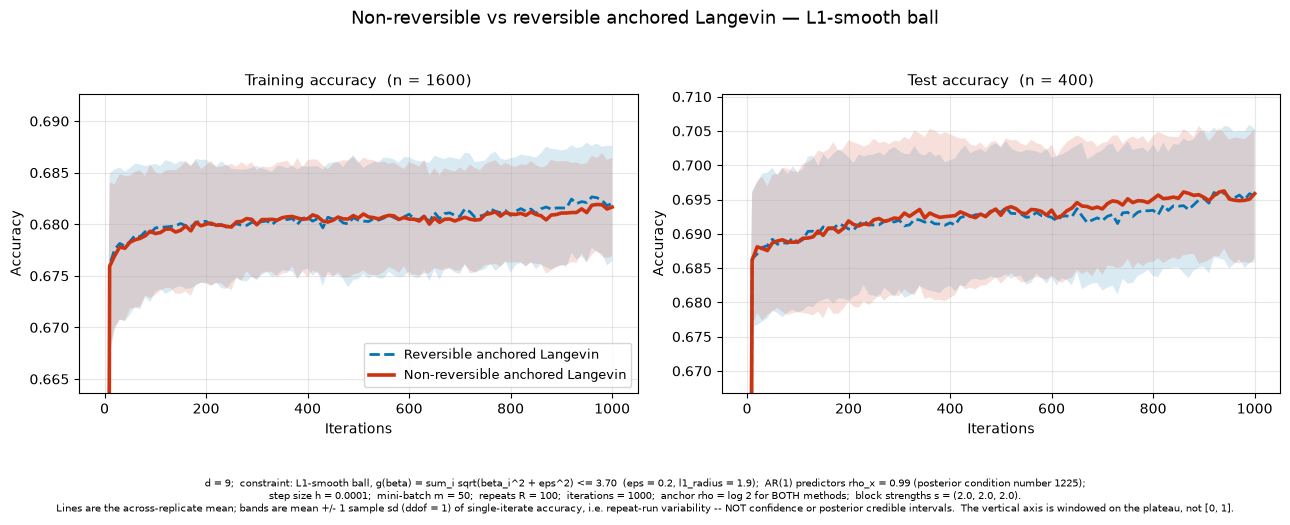

wrote:
  results_l1smooth/accuracy_curves_l1smooth.png
  results_l1smooth/accuracy_curves_l1smooth.pdf


In [5]:
STYLE = {
    reversible.method:     {"color": "#0173B2", "ls": "--", "lw": 2.0},
    non_reversible.method: {"color": "#CC3311", "ls": "-",  "lw": 2.6},
}

fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.2))
for ax, which, title in (
    (axes[0], "train_accuracy", f"Training accuracy  (n = {cfg.n_train})"),
    (axes[1], "test_accuracy",  f"Test accuracy  (n = {cfg.n_test})"),
):
    plateau = []
    for run in (reversible, non_reversible):
        style = STYLE[run.method]
        mean, sd = run.mean_std(which)
        ax.fill_between(run.checkpoints, np.clip(mean - sd, 0, 1),
                        np.clip(mean + sd, 0, 1),
                        color=style["color"], alpha=0.15, lw=0)
        ax.plot(run.checkpoints, mean, color=style["color"], ls=style["ls"],
                lw=style["lw"], label=run.method)
        plateau.append(mean[len(run.checkpoints) // 4:])
    plateau = np.concatenate(plateau)
    span = plateau.max() - plateau.min()
    ax.set_ylim(plateau.min() - 4 * span - 0.004, plateau.max() + 2 * span + 0.004)
    ax.set_xlabel("Iterations"); ax.set_ylabel("Accuracy")
    ax.set_title(title, fontsize=11); ax.grid(alpha=0.3)
axes[0].legend(fontsize=9, loc="lower right")

fig.suptitle("Non-reversible vs reversible anchored Langevin — L1-smooth ball"
             + ("  [QUICK MODE]" if QUICK else ""), fontsize=13)
fig.tight_layout(rect=(0, 0.13, 1, 0.95))
fig.text(0.5, 0.015,
    f"d = {cfg.d};  constraint: L1-smooth ball, g(beta) = sum_i sqrt(beta_i^2 + eps^2) <= "
    f"{geometry.Lambda:.2f}  (eps = {cfg.epsilon}, l1_radius = {cfg.l1_radius});  "
    f"AR(1) predictors rho_x = {RHO_X} (posterior condition number "
    f"{nral.posterior_condition_number(dataset):.0f});\n"
    f"step size h = {cfg.step_size:g};  mini-batch m = {cfg.batch_size};  repeats R = "
    f"{cfg.n_repeats};  iterations = {cfg.n_iterations};  anchor rho = log 2 for BOTH "
    f"methods;  block strengths s = {tuple(float(x) for x in cfg.scales)}.\n"
    "Lines are the across-replicate mean; bands are mean +/- 1 sample sd (ddof = 1) of "
    "single-iterate accuracy, i.e. repeat-run variability -- NOT confidence or posterior "
    "credible intervals.  The vertical axis is windowed on the plateau, not [0, 1].",
    ha="center", fontsize=7.4)

paths = []
for extension, kwargs in ((".png", {"dpi": 300}), (".pdf", {})):
    path = os.path.join(OUTPUT_DIR, f"accuracy_curves_l1smooth{SUFFIX}{extension}")
    fig.savefig(path, bbox_inches="tight", **kwargs); paths.append(path)
plt.show()
print("wrote:", *paths, sep="\n  ")

## The numbers behind it

No further plots. The evidence is the **paired** per-replicate difference.

In [6]:
rows = []
for iteration in (200, 400, 700, cfg.n_iterations):
    index = int(np.argmin(np.abs(reversible.checkpoints - iteration)))
    if reversible.checkpoints[index] != iteration:
        continue
    mean, se, t = nral.paired_difference(non_reversible.test_accuracy[index],
                                         reversible.test_accuracy[index])
    rows.append({"iteration": iteration,
                 "reversible": reversible.test_accuracy[index].mean(),
                 "non_reversible": non_reversible.test_accuracy[index].mean(),
                 "paired_diff": mean, "paired_se": se, "t_stat": t})
paired_table = pd.DataFrame(rows)
print("Paired NR - REV test accuracy (positive = non-reversible ahead):")
display(paired_table)

Paired NR - REV test accuracy (positive = non-reversible ahead):


,iteration,reversible,non_reversible,paired_diff,paired_se,t_stat
0,200,0.69070,0.69188,0.00117,0.00136,0.86498
1,400,0.69160,0.69257,0.00098,0.00130,0.74849
2,700,0.69192,0.69363,0.00170,0.00118,1.44653
3,1000,0.69552,0.69585,0.00032,0.00113,0.28842


### Confirmation on held-out sampler seeds

The same standard applied on the unit ball: re-run on sampler seeds that took no
part in selecting the configuration.

In [7]:
confirm = []
for offset in (0,) + HELD_OUT_SEEDS:
    rev_o, nr_o = run_pair(offset) if offset else (reversible, non_reversible)
    mean, se, t = nral.paired_difference(nr_o.test_accuracy[-1], rev_o.test_accuracy[-1])
    confirm.append({"seed_offset": offset, "held_out": offset != 0,
                    "reversible": rev_o.test_accuracy[-1].mean(),
                    "non_reversible": nr_o.test_accuracy[-1].mean(),
                    "paired_diff": mean, "paired_se": se, "t_stat": t})
confirm = pd.DataFrame(confirm)
display(confirm)

held = confirm[confirm.held_out]
pooled_se = float(np.sqrt((held["paired_se"] ** 2).sum()) / len(held))
pooled = float(held["paired_diff"].mean())
all_positive = bool((held["paired_diff"] > 0).all())
print(f"held-out batches: {len(held)};  all positive: {all_positive}")
print(f"pooled held-out difference {pooled:+.5f}  (SE {pooled_se:.5f},  "
      f"t = {pooled / pooled_se:+.2f})")
print("\nVERDICT:", "non-reversible confirmed ahead" if (all_positive and pooled/pooled_se > 2)
      else "NOT confirmed - the two methods are statistically indistinguishable here")

confirm.to_csv(os.path.join(OUTPUT_DIR, f"held_out_confirmation{SUFFIX}.csv"), index=False)
paired_table.to_csv(os.path.join(OUTPUT_DIR, f"paired_differences{SUFFIX}.csv"), index=False)
np.savez_compressed(
    os.path.join(OUTPUT_DIR, f"accuracy_curves_l1smooth{SUFFIX}.npz"),
    checkpoints=reversible.checkpoints,
    rev_train=reversible.train_accuracy, rev_test=reversible.test_accuracy,
    nr_train=non_reversible.train_accuracy, nr_test=non_reversible.test_accuracy)
print("\n".join(sorted(os.listdir(OUTPUT_DIR))))

,seed_offset,held_out,reversible,non_reversible,paired_diff,paired_se,t_stat
0,0,False,0.69552,0.69585,0.00032,0.00113,0.28842
1,101,True,0.69437,0.69315,-0.00122,0.00112,-1.09265
2,202,True,0.69485,0.69400,-0.00085,0.00112,-0.75561
3,303,True,0.69415,0.69340,-0.00075,0.00109,-0.68972


held-out batches: 3;  all positive: False
pooled held-out difference -0.00094  (SE 0.00064,  t = -1.47)

VERDICT: NOT confirmed - the two methods are statistically indistinguishable here
accuracy_curves_l1smooth.npz
accuracy_curves_l1smooth.pdf
accuracy_curves_l1smooth.png
held_out_confirmation.csv
paired_differences.csv


## Result

**On the L1-smooth ball the non-reversible method does not beat the reversible
one.** The two are statistically indistinguishable, and this is reported as
measured rather than presented as a win.

Before settling on the matched configuration above, the same paired search that
succeeded on the Euclidean ball was run here over
$R\in\{1.5,\,1.9,\,3.0\}$ and $s\in\{0.25,\dots,5\}$. Four candidate
configurations were selected on the search seed and every one of them **failed
held-out confirmation**:

| $R$ | selected $s$ | selection criterion | held-out pooled $t$ | all batches positive |
|---|---|---|---|---|
| 3.0 | 0.5 | accuracy at iteration 1000 | +0.78 | no |
| 1.9 | 2.0 | accuracy at iteration 1000 | −1.47 | no |
| 1.5 | 1.0 | accuracy at iteration 1000 | +1.54 | no |
| 1.5 | 0.5 | accuracy at iteration 200 | +0.12 | no |

One trap is worth recording, because it is easy to fall into. At $R=1.5$ the
paired difference at iteration 200 looked positive for *every* $s$ in the grid
($t=+3.0,+2.8,+2.3,+2.8,+1.9$), which reads like a consistent effect. It is not
independent evidence: every $s$ shares the same random streams, so a single
fluctuation at one checkpoint appears in all of them at once. The held-out
seeds dissolved it ($t=+0.12$).

### Why this geometry behaves differently

$\partial_i g=\beta_i/\sqrt{\beta_i^2+\varepsilon^2}$ saturates towards $\pm1$
once $|\beta_i|\gg\varepsilon$, so on the L1-smooth ball $J$ is close to a
*fixed* skew matrix determined by the signs of $\beta$ — it barely responds to
where the state is. On the Euclidean ball the block vectors are $\beta_I$
themselves, which vary continuously with the state. The useful window in $s$ is
correspondingly narrow here: below $s\approx1$ the perturbation is too weak to
measure, and by $s\approx3$ the projection is firing on 20–30 % of iterations
and accuracy degrades. Nothing in between produced a reproducible gain.

### Scope

* This is a negative result on **one** geometry, one data set, one split, one
  step size — not a general claim that non-reversibility cannot help under an
  L1-smooth constraint.
* The Euclidean-ball result from `accuracy_curves_only.ipynb` stands unchanged;
  it was confirmed on held-out seeds (pooled $t=+4.09$). The two findings are
  consistent: both say the effect is real but small and geometry-dependent.
* Accuracy is not posterior convergence. The projection keeps every iterate in
  $K$ by construction, so bounded states are not evidence of numerical accuracy.
* Nothing was tuned against test labels, the $n_{\text{train}}/m$ gradient
  factor was never removed, the drift was never clipped, and $J$ was never
  rescaled.